# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [35]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

*Note ici les métriques de référence (F1 macro, ROC-AUC sur validation 2017), les features utilisées, l'architecture du modèle.*

## 2. EDA du nouveau dataset

Au moins 3 visualisations + un paragraphe sur ce qui diffère du dataset 2017.

In [36]:
# Charger l'ancien dataset (2017 baseline)
df_old = pd.read_csv(Path('../../pyrenex-risk-v1/data/lending_club_2017_subset.csv'))
df_new = pd.read_csv(DATA_DIR / 'lending_club_train.csv')

print("=" * 60)
print("COMPARAISON DATASETS 2017 (BASELINE) vs NOUVEAU")
print("=" * 60)
print(f"\nAncien dataset (2017): {df_old.shape}")
print(f"Nouveau dataset:      {df_new.shape}")
print(f"Différence en lignes: {df_new.shape[0] - df_old.shape[0]:+d} ({(df_new.shape[0] / df_old.shape[0] - 1) * 100:+.1f}%)")
print(f"\nColonnes en commun: {len(set(df_old.columns) & set(df_new.columns))} / {len(set(df_old.columns) | set(df_new.columns))}")
print(f"Colonnes seulement en ancien: {set(df_old.columns) - set(df_new.columns)}")
print(f"Colonnes seulement en nouveau: {set(df_new.columns) - set(df_old.columns)}")


COMPARAISON DATASETS 2017 (BASELINE) vs NOUVEAU

Ancien dataset (2017): (12000, 15)
Nouveau dataset:      (24000, 15)
Différence en lignes: +12000 (+100.0%)

Colonnes en commun: 15 / 15
Colonnes seulement en ancien: set()
Colonnes seulement en nouveau: set()


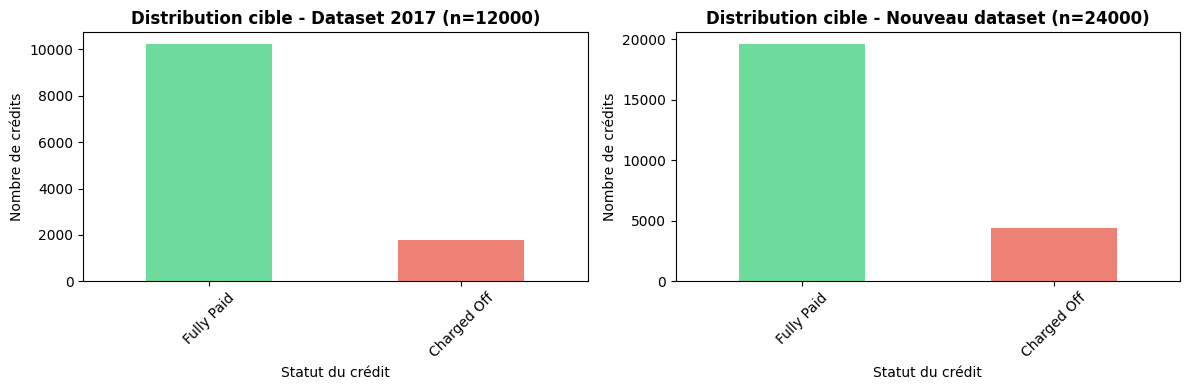

PROPORTION DE CHAQUE CLASSE

2017 (12000 crédits):
loan_status
Fully Paid     85.2
Charged Off    14.8
Name: proportion, dtype: float64

Nouveau (24000 crédits):
loan_status
Fully Paid     81.6
Charged Off    18.4
Name: proportion, dtype: float64


In [37]:
target_col = 'loan_status'

# Compter les classes dans chaque dataset
counts_old = df_old[target_col].value_counts()
counts_new = df_new[target_col].value_counts()

# Créer 2 graphes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dataset 2017
counts_old.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0].set_title(f'Distribution cible - Dataset 2017 (n={len(df_old)})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de crédits')
axes[0].set_xlabel('Statut du crédit')
axes[0].tick_params(axis='x', rotation=45)

# Dataset Nouveau
counts_new.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[1].set_title(f'Distribution cible - Nouveau dataset (n={len(df_new)})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre de crédits')
axes[1].set_xlabel('Statut du crédit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Afficher les proportions
print("=" * 60)
print("PROPORTION DE CHAQUE CLASSE")
print("=" * 60)
print(f"\n2017 ({len(df_old)} crédits):")
print(df_old[target_col].value_counts(normalize=True).mul(100).round(1))

print(f"\nNouveau ({len(df_new)} crédits):")
print(df_new[target_col].value_counts(normalize=True).mul(100).round(1))

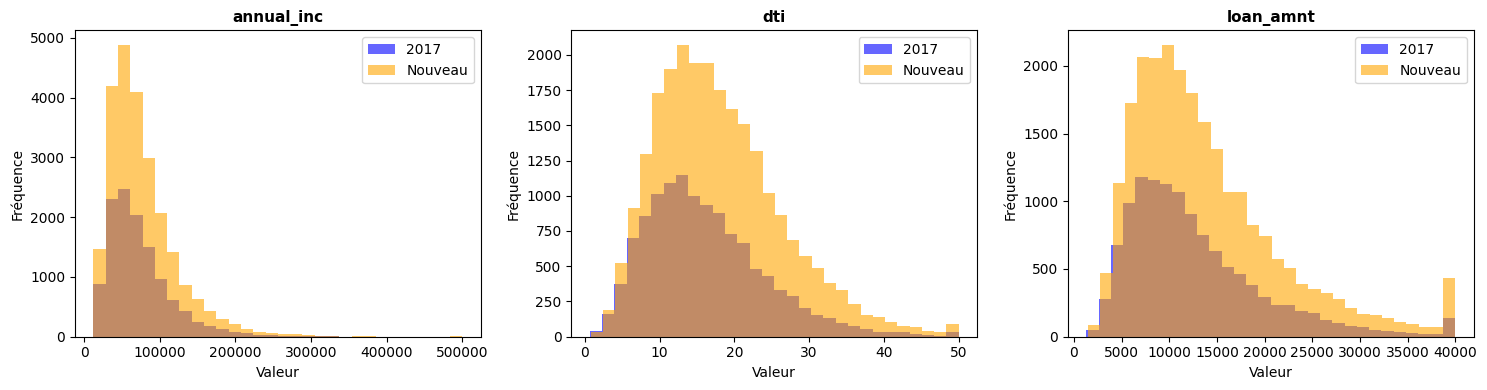

COMPARAISON DES FEATURES CLÉS

annual_inc:
  2017    → moy: 73114.9, médiane: 63000.0
  Nouveau → moy: 77199.7, médiane: 66200.0
  Différence: +5.6%

dti:
  2017    → moy: 16.1, médiane: 14.8
  Nouveau → moy: 18.0, médiane: 16.8
  Différence: +11.7%

loan_amnt:
  2017    → moy: 12675.3, médiane: 11000.0
  Nouveau → moy: 13868.1, médiane: 12000.0
  Différence: +9.4%


In [38]:
key_features = ['annual_inc', 'dti', 'loan_amnt']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feat in enumerate(key_features):
    # Histogrammes superposés
    axes[idx].hist(df_old[feat].dropna(), bins=30, alpha=0.6, label='2017', color='blue')
    axes[idx].hist(df_new[feat].dropna(), bins=30, alpha=0.6, label='Nouveau', color='orange')
    axes[idx].set_title(f'{feat}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Afficher les stats
print("=" * 60)
print("COMPARAISON DES FEATURES CLÉS")
print("=" * 60)
for feat in key_features:
    print(f"\n{feat}:")
    print(f"  2017    → moy: {df_old[feat].mean():.1f}, médiane: {df_old[feat].median():.1f}")
    print(f"  Nouveau → moy: {df_new[feat].mean():.1f}, médiane: {df_new[feat].median():.1f}")
    diff = ((df_new[feat].mean() / df_old[feat].mean()) - 1) * 100
    print(f"  Différence: {diff:+.1f}%")

### Visualisations Seaborn

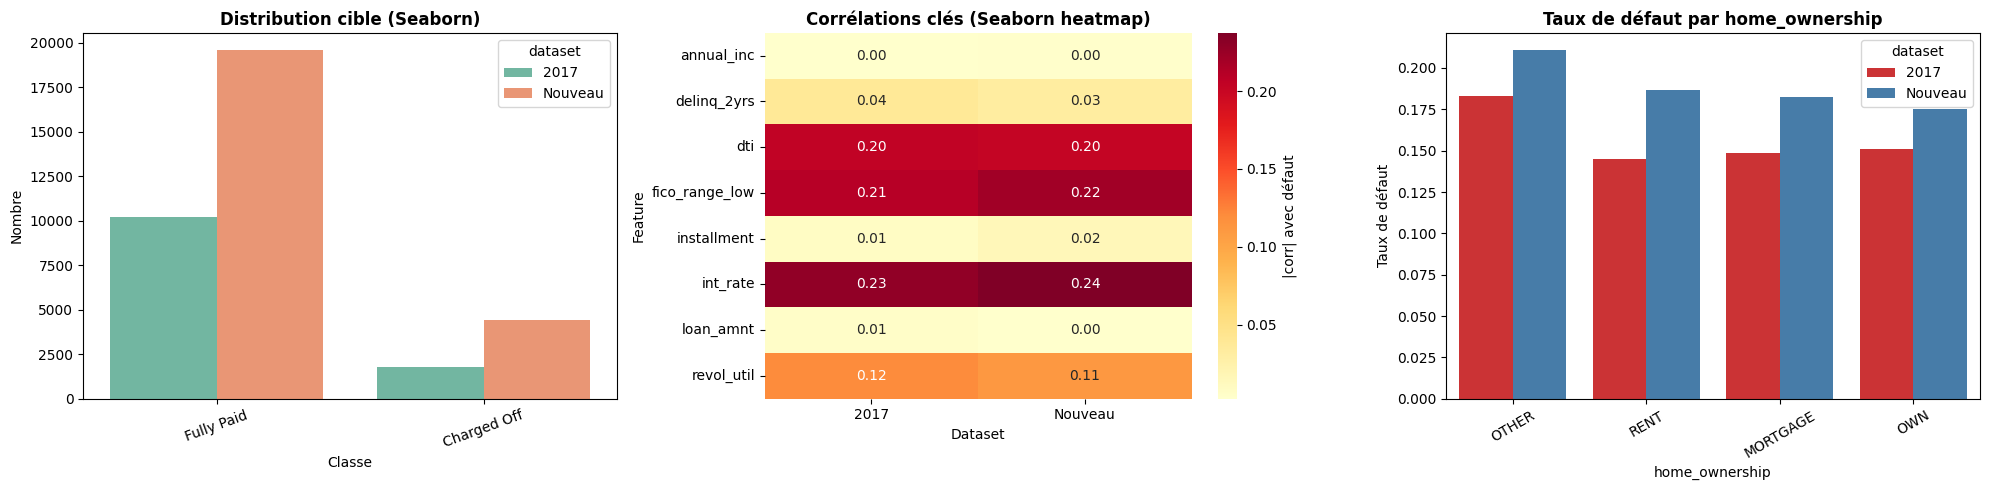

In [39]:
# 1) Distribution de la cible (comparaison baseline vs nouveau)
plot_old = df_old[[target_col]].copy()
plot_old['dataset'] = '2017'
plot_new = df_new[[target_col]].copy()
plot_new['dataset'] = 'Nouveau'
plot_target = pd.concat([plot_old, plot_new], axis=0, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(
    data=plot_target,
    x=target_col,
    hue='dataset',
    order=['Fully Paid', 'Charged Off'],
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Distribution cible (Seaborn)', fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=20)

# 2) Corrélations clés avec la cible (heatmap)
def _corr_with_target(df_in, label):
    tmp = df_in.copy()
    tmp['target_bin'] = (tmp[target_col] == 'Charged Off').astype(int)
    corr = tmp.select_dtypes(include=[np.number]).corr(numeric_only=True)['target_bin'].drop('target_bin')
    corr = corr.abs().sort_values(ascending=False).head(8)
    out = corr.to_frame(name=label)
    return out

corr_old_top = _corr_with_target(df_old, '2017')
corr_new_top = _corr_with_target(df_new, 'Nouveau')
heat = corr_old_top.join(corr_new_top, how='outer').fillna(0)

sns.heatmap(
    heat,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': '|corr| avec défaut'},
    ax=axes[1]
)
axes[1].set_title('Corrélations clés (Seaborn heatmap)', fontweight='bold')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Feature')

# 3) Variable sensible : home_ownership vs taux de défaut
sensitive_col = 'home_ownership'
if sensitive_col in df_old.columns and sensitive_col in df_new.columns:
    sens_old = df_old[[sensitive_col, target_col]].copy()
    sens_old['dataset'] = '2017'
    sens_new = df_new[[sensitive_col, target_col]].copy()
    sens_new['dataset'] = 'Nouveau'
    sens = pd.concat([sens_old, sens_new], axis=0, ignore_index=True)
    sens['default_rate'] = (sens[target_col] == 'Charged Off').astype(int)

    order = (
        sens.groupby(sensitive_col)['default_rate']
        .mean()
        .sort_values(ascending=False)
        .index
    )

    sns.barplot(
        data=sens,
        x=sensitive_col,
        y='default_rate',
        hue='dataset',
        order=order,
        palette='Set1',
        estimator=np.mean,
        errorbar=None,
        ax=axes[2]
    )
    axes[2].set_title('Taux de défaut par home_ownership', fontweight='bold')
    axes[2].set_xlabel('home_ownership')
    axes[2].set_ylabel('Taux de défaut')
    axes[2].tick_params(axis='x', rotation=30)
else:
    axes[2].text(0.5, 0.5, 'Colonne home_ownership absente', ha='center', va='center')
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

## 3. Préparation et split

Split stratifié, `random_state=42`.

In [40]:
import sys
from pathlib import Path

from sklearn.model_selection import train_test_split

# Rendre importable le dossier src depuis le notebook
src_dir = (Path.cwd() / "../src").resolve()
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from preprocess import build_preprocessor, load_dataset

In [41]:
X, y = load_dataset(DATA_DIR / "lending_club_train.csv")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Shapes")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nClass ratio (global):")
print(y.value_counts(normalize=True).round(4))
print("\nClass ratio (train):")
print(y_train.value_counts(normalize=True).round(4))
print("\nClass ratio (test):")
print(y_test.value_counts(normalize=True).round(4))

Shapes
X_train: (19200, 14)
X_test : (4800, 14)
y_train: (19200,)
y_test : (4800,)

Class ratio (global):
loan_status
0    0.8161
1    0.1839
Name: proportion, dtype: float64

Class ratio (train):
loan_status
0    0.8161
1    0.1839
Name: proportion, dtype: float64

Class ratio (test):
loan_status
0    0.816
1    0.184
Name: proportion, dtype: float64


In [42]:
preprocessor = build_preprocessor()

# Fit uniquement sur train
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Processed shapes")
print("X_train_proc:", X_train_proc.shape)
print("X_test_proc :", X_test_proc.shape)

# Vérif rapide
print("\nNaN in train:", np.isnan(X_train_proc).sum())
print("NaN in test :", np.isnan(X_test_proc).sum())

Processed shapes
X_train_proc: (19200, 43)
X_test_proc : (4800, 43)

NaN in train: 0
NaN in test : 0


## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

### Benchmark RandomForest — Jeu A vs Jeu B

Justification rapide :
- Jeu A sert de référence neutre (valeurs par défaut scikit-learn).
- Jeu B augmente la capacité (`n_estimators=200`) tout en régularisant (`max_depth=10`) et en compensant le déséquilibre (`class_weight='balanced'`).

On évalue uniquement sur le test interne issu de `lending_club_train.csv` (pas de holdout ici).

In [43]:
from pathlib import Path
import pandas as pd
from train import train

data_path = Path("../data/lending_club_train.csv")
output_dir = Path("../models")

# RandomForest benchmark
res_a = train("default", data_path, output_dir)
res_b = train("balanced", data_path, output_dir)

# Variante A : Gradient Boosting + SHAP
res_gb = train("gb_variant_a", data_path, output_dir)

rows = [
    {"config": "default", **res_a["metrics"]},
    {"config": "balanced", **res_b["metrics"]},
    {"config": "gb_variant_a", **res_gb["metrics"]},
]

bench = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(bench)

print("Model A:", res_a["model_path"])
print("Model B:", res_b["model_path"])
print("Model GB:", res_gb["model_path"])
print("SHAP plots:", res_gb.get("shap_plots", []))

,config,f1_macro,roc_auc
1,balanced,0.612325,0.744171
2,gb_variant_a,0.520745,0.742958
0,default,0.513078,0.717038


Model A: ..\models\pyrenex_risk_v2_default.joblib
Model B: ..\models\pyrenex_risk_v2_balanced.joblib
Model GB: ..\models\pyrenex_risk_v2_gb_variant_a.joblib
SHAP plots: ['..\\models\\shap_bar_gb_variant_a.png', '..\\models\\shap_summary_gb_variant_a.png']


### Variante A — Gradient Boosting + SHAP

La variante est entraînée dans la cellule précédente via `train("gb_variant_a", data_path, output_dir)`.
Si SHAP est installé, deux graphiques sont générés et sauvegardés dans `../models/`.

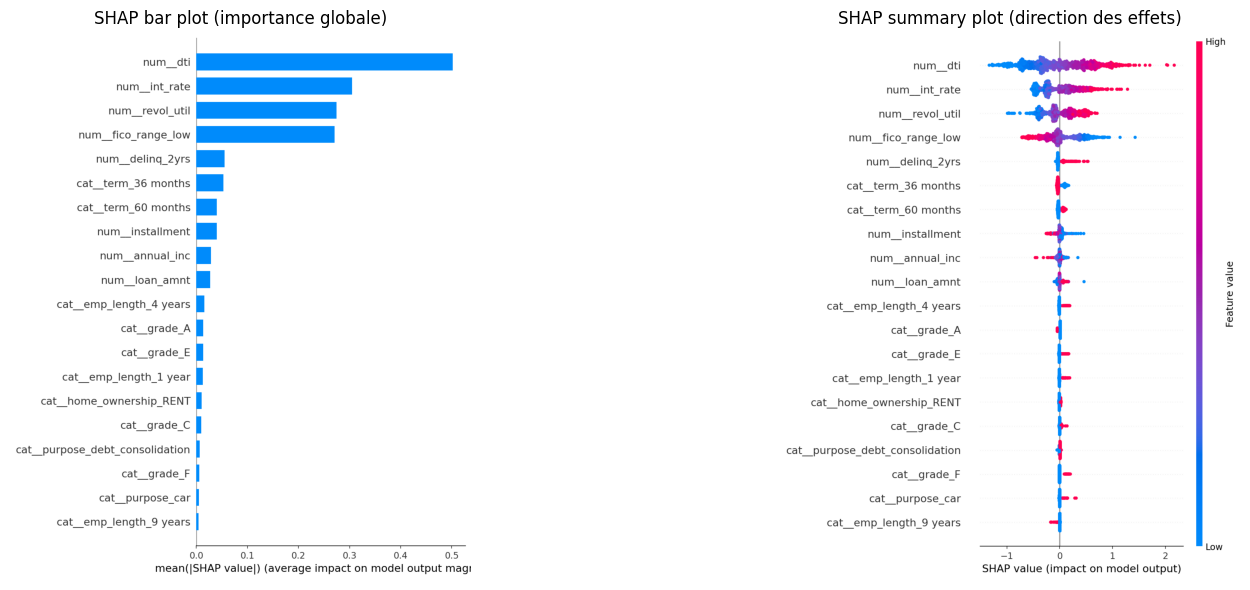

In [44]:
# Afficher les 2 plots SHAP générés par train.py
from matplotlib import image as mpimg

shap_bar = output_dir / "shap_bar_gb_variant_a.png"
shap_summary = output_dir / "shap_summary_gb_variant_a.png"

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if shap_bar.exists():
    axes[0].imshow(mpimg.imread(shap_bar))
    axes[0].set_title("SHAP bar plot (importance globale)")
    axes[0].axis("off")
else:
    axes[0].text(0.5, 0.5, f"Fichier introuvable:\n{shap_bar}", ha="center", va="center")
    axes[0].axis("off")

if shap_summary.exists():
    axes[1].imshow(mpimg.imread(shap_summary))
    axes[1].set_title("SHAP summary plot (direction des effets)")
    axes[1].axis("off")
else:
    axes[1].text(0.5, 0.5, f"Fichier introuvable:\n{shap_summary}", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

### Discussion — apport de l'explicabilité SHAP pour le client crédit

Points à discuter dans ton notebook :
- **Transparence** : SHAP montre les facteurs qui poussent un dossier vers le défaut (ex. `int_rate`, `dti`).
- **Confiance métier** : les analystes risque peuvent vérifier que le modèle suit une logique crédible.
- **Aide à la décision** : on peut expliquer une décision client (accord/refus) avec des raisons quantitatives.
- **Surveillance des biais** : si une variable sensible domine, cela alerte sur un risque de biais.
- **Limite** : SHAP explique le modèle, pas la causalité réelle du défaut.

## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Vérifier la stabilité du score pour la config retenue (exp_002: RF balanced)
seeds = [0, 1, 42, 100, 2024]
score_rows = []

for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed,
    )

    # Refit preprocessing à chaque split pour éviter toute fuite
    preproc_seed = build_preprocessor()
    X_tr_proc = preproc_seed.fit_transform(X_tr)
    X_te_proc = preproc_seed.transform(X_te)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_tr_proc, y_tr)

    y_pred = model.predict(X_te_proc)
    f1 = f1_score(y_te, y_pred, average="macro")
    score_rows.append({"seed": seed, "f1_macro": f1})
    print(f"seed={seed:>4} -> F1 macro = {f1:.4f}")

scores_df = pd.DataFrame(score_rows)
spread = scores_df["f1_macro"].max() - scores_df["f1_macro"].min()

print(f"\nF1 macro moyen : {scores_df['f1_macro'].mean():.4f}")
print(f"Écart min-max  : {spread:.4f}")
display(scores_df)

seed=   0 -> F1 macro = 0.6013
seed=   1 -> F1 macro = 0.6162
seed=  42 -> F1 macro = 0.6123
seed= 100 -> F1 macro = 0.6158
seed=2024 -> F1 macro = 0.5939

F1 macro moyen : 0.6079
Écart min-max  : 0.0223


,seed,f1_macro
0,0,0.601267
1,1,0.616229
2,42,0.612325
3,100,0.615813
4,2024,0.593903


**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

F1 macro: 0.6123
F1 défaut: 0.4357
ROC-AUC: 0.737


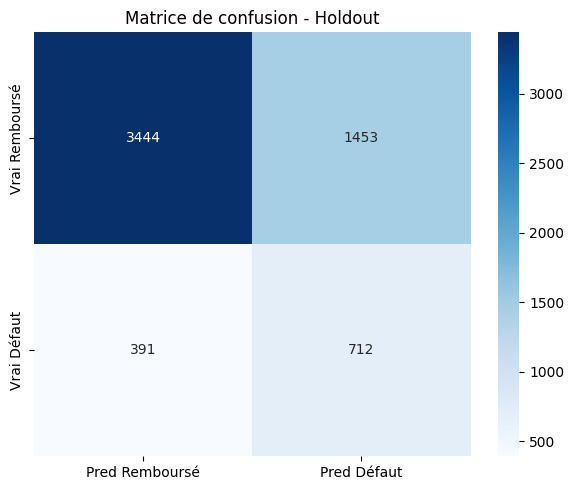

,precision,recall,f1-score,support
Remboursé,0.898044,0.703288,0.788823,4897.000000
Défaut,0.328868,0.645512,0.435741,1103.000000
accuracy,0.692667,0.692667,0.692667,0.692667
macro avg,0.613456,0.674400,0.612282,6000.000000
weighted avg,0.793411,0.692667,0.723914,6000.000000


In [46]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from evaluate import evaluate

# Évaluer le modèle retenu sur holdout (tâche 5)
metrics_holdout = evaluate(
    model_path=Path("../models/pyrenex_risk_v2_balanced.joblib"),
    data_path=Path("../data/lending_club_holdout.csv"),
)

print("F1 macro:", metrics_holdout["f1_macro"])
print("F1 défaut:", metrics_holdout["f1_default"])
print("ROC-AUC:", metrics_holdout["roc_auc"])

cm = metrics_holdout["confusion_matrix"]
cm_df = pd.DataFrame(
    cm,
    index=["Vrai Remboursé", "Vrai Défaut"],
    columns=["Pred Remboursé", "Pred Défaut"],
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - Holdout")
plt.tight_layout()
plt.show()

report_df = pd.DataFrame(metrics_holdout["classification_report"]).T
display(report_df)


## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.